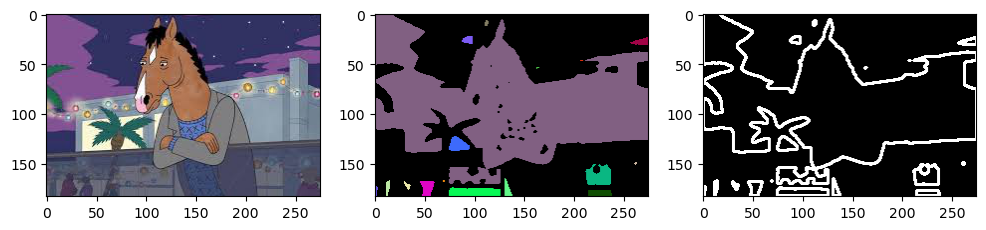

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread("image.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#combino tecnicas 
blur = cv2.GaussianBlur(gray, (7,7), 0)
_,binary = cv2.threshold(blur,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
#ENCONTRAMOS REGIONES
num_l,label = cv2.connectedComponents(binary)
#idetificamos por colores
color = np.random.randint(0,255,size = (num_l,3),dtype=np.uint8)
#fondo negro
color[0] = [0,0,0]
colorear = color[label]

#encotrar fronteras
contornos,_=cv2.findContours(binary,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
contono_fin = cv2.drawContours(np.zeros_like(gray),contornos,-1,255,2)

plt.figure(figsize=(12, 6))
plt.subplot(131)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(132)
plt.imshow(colorear)
plt.subplot(133)
plt.imshow(contono_fin,cmap='gray')
plt.show()

CONTEO  

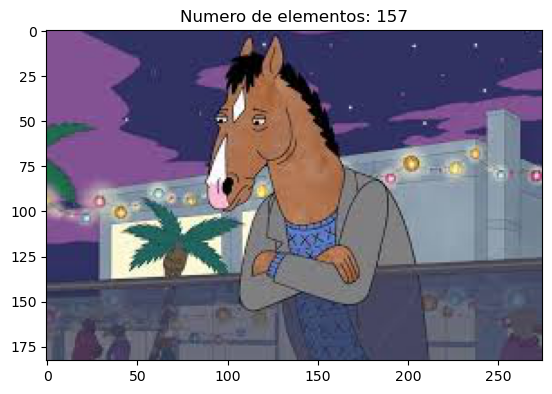

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar_elementos(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    
    e_img = measure.label(binary, connectivity=2) #2=concetividad es de 4  1=conectividad de 8
    num_obj = np.max(e_img)
    
    return num_obj

imagen = cv2.imread("images1.jpg")
conteo=contar_elementos(imagen)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title(f"Numero de elementos: {conteo}")
plt.show()


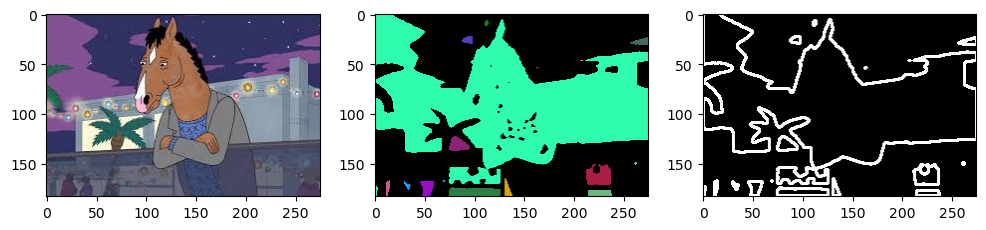

totall regiones 18

color 0 , 0 , 0 objetos 25611
color 47 , 252 , 174 objetos 22984
color 0 , 141 , 41 objetos 19
color 82 , 62 , 180 objetos 69
color 68 , 104 , 99 objetos 99
color 216 , 136 , 2 objetos 3
color 51 , 96 , 19 objetos 4
color 140 , 34 , 118 objetos 216
color 78 , 209 , 200 objetos 6
color 171 , 30 , 70 objetos 416
color 214 , 167 , 6 objetos 84
color 203 , 91 , 139 objetos 49
color 3 , 212 , 112 objetos 4
color 16 , 157 , 245 objetos 28
color 152 , 13 , 199 objetos 161
color 50 , 252 , 195 objetos 23
color 44 , 126 , 69 objetos 408
color 112 , 183 , 131 objetos 141

total fronteras 17


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("images1.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#combino tecnicas 
blur = cv2.GaussianBlur(gray, (7,7), 0)
_,binary = cv2.threshold(blur,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
#ENCONTRAMOS REGIONES
num_l,label = cv2.connectedComponents(binary)
#idetificamos por colores
color = np.random.randint(0,255,size = (num_l,3),dtype=np.uint8)
#fondo negro
color[0] = [0,0,0]
colorear = color[label]
contornos,_=cv2.findContours(binary,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
contono_fin = cv2.drawContours(np.zeros_like(gray),contornos,-1,255,2)
plt.figure(figsize=(12, 6))
plt.subplot(131)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(132)
plt.imshow(colorear)
plt.subplot(133)
plt.imshow(contono_fin,cmap='gray')
plt.show()
print("totall regiones", num_l)
print()

for i in range(num_l):
    cantidad = np.sum(label == i)
    print("color", color[i][0], ",", color[i][1], ",", color[i][2], "objetos", cantidad)
print()
print("total fronteras", len(contornos))